In [102]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [103]:
pd.set_option('display.max_columns', None)
dfInit = pd.read_csv('./student_lifestyle_dataset.csv', delimiter=',', encoding='utf-8')
df = dfInit.copy(deep=True)
display(df)

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Stress_Level,Gender,Grades
0,1,6.9,3.8,8.7,2.8,1.8,Moderate,Male,7.48
1,2,5.3,3.5,8.0,4.2,3.0,Low,Female,6.88
2,3,5.1,3.9,9.2,1.2,4.6,Low,Male,6.68
3,4,6.5,2.1,7.2,1.7,6.5,Moderate,Male,7.20
4,5,8.1,0.6,6.5,2.2,6.6,High,Male,8.78
...,...,...,...,...,...,...,...,...,...
1995,1996,6.5,0.2,7.4,2.1,7.8,Moderate,Male,8.30
1996,1997,6.3,2.8,8.8,1.5,4.6,Moderate,Female,6.62
1997,1998,6.2,0.0,6.2,0.8,10.8,Moderate,Male,7.85
1998,1999,8.1,0.7,7.6,3.5,4.1,High,Male,7.60


In [104]:
genderDict = { "Male" : 0, "Female" : 1 }
stressDict = {"Low" : 0, "High" : 1, "Moderate" : 2}
df["Gender"] = df["Gender"].map(lambda elem : genderDict[elem])
df["Stress_Level"] = df["Stress_Level"].map(lambda elem : stressDict[elem])
df["Activity_Ratio"] = df["Physical_Activity_Hours_Per_Day"] / (df["Study_Hours_Per_Day"] + 1e-3)
df["Sleep_Efficiency"] = df["Sleep_Hours_Per_Day"] / 24
df["Social_Ratio"] = df["Social_Hours_Per_Day"] / (df["Extracurricular_Hours_Per_Day"] + 1e-3)
display(df)

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Stress_Level,Gender,Grades,Activity_Ratio,Sleep_Efficiency,Social_Ratio
0,1,6.9,3.8,8.7,2.8,1.8,2,0,7.48,0.260832,0.362500,0.736648
1,2,5.3,3.5,8.0,4.2,3.0,0,1,6.88,0.565931,0.333333,1.199657
2,3,5.1,3.9,9.2,1.2,4.6,0,0,6.68,0.901784,0.383333,0.307613
3,4,6.5,2.1,7.2,1.7,6.5,2,0,7.20,0.999846,0.300000,0.809139
4,5,8.1,0.6,6.5,2.2,6.6,1,0,8.78,0.814714,0.270833,3.660566
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,6.5,0.2,7.4,2.1,7.8,2,0,8.30,1.199815,0.308333,10.447761
1996,1997,6.3,2.8,8.8,1.5,4.6,2,1,6.62,0.730043,0.366667,0.535523
1997,1998,6.2,0.0,6.2,0.8,10.8,2,0,7.85,1.741655,0.258333,800.000000
1998,1999,8.1,0.7,7.6,3.5,4.1,1,0,7.60,0.506110,0.316667,4.992867


In [105]:
ordered_features = [
    "Study_Hours_Per_Day", "Grades", "Extracurricular_Hours_Per_Day",
    "Physical_Activity_Hours_Per_Day", "Sleep_Hours_Per_Day", "Social_Hours_Per_Day",
    "Gender", "Activity_Ratio", "Sleep_Efficiency", "Social_Ratio"
]

X_core = df[ordered_features].values
X_padded = np.hstack([X_core, np.zeros((X_core.shape[0], 6))])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_padded)

#1 канал
# X_reshaped = X_scaled.reshape(-1, 1, 4, 4)

#2 канала
X_binary = (X_scaled > 0).astype(float)
X_image_1 = X_scaled.reshape(-1, 4, 4)
X_image_2 = X_binary.reshape(-1, 4, 4)
X_reshaped = np.stack([X_image_1, X_image_2], axis=1)

y = df["Stress_Level"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y, test_size=0.2, random_state=42, stratify=y
)

In [106]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [107]:
class StressLevelCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            #1 канал
            # nn.Conv2d(1, 16, kernel_size=3, padding=1),
            #2 канала
            nn.Conv2d(2, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 2 * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [108]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = StressLevelCNN().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

n_epochs = 15
for epoch in range(n_epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, loss: {total_loss:.4f}")

Epoch 1, loss: 42.7136
Epoch 2, loss: 26.8052
Epoch 3, loss: 20.1646
Epoch 4, loss: 16.8435
Epoch 5, loss: 14.2228
Epoch 6, loss: 11.8966
Epoch 7, loss: 11.8547
Epoch 8, loss: 10.5403
Epoch 9, loss: 8.8858
Epoch 10, loss: 8.3436
Epoch 11, loss: 8.4659
Epoch 12, loss: 7.0887
Epoch 13, loss: 7.5184
Epoch 14, loss: 6.0255
Epoch 15, loss: 5.9759


In [109]:
model.eval()
correct = 0
total = 0

all_preds = []
all_labels = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        pred_labels = pred.argmax(dim=1)
        correct += (pred_labels == yb).sum().item()
        total += yb.size(0)
        all_preds.extend(pred_labels.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

print(f"Accuracy : {correct / total:.4f}")

Accuracy : 0.9500


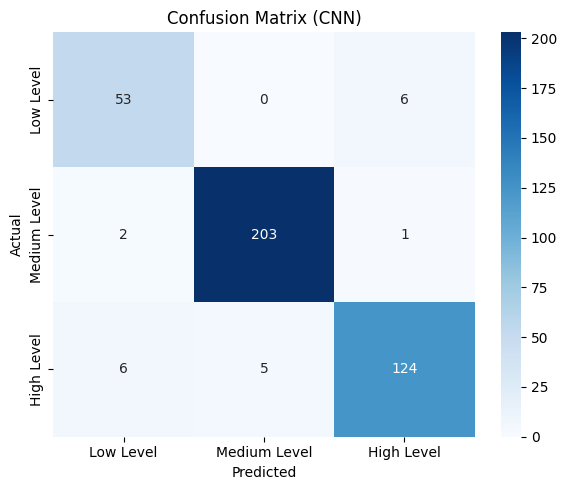

In [110]:
cm = confusion_matrix(all_labels, all_preds)

class_names = ['Low Level', 'Medium Level', "High Level"]
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (CNN)')
plt.tight_layout()
plt.show()